# Task 06 – Exploratory Data Analysis (EDA) Using Jupyter Notebook

## Part A – Dataset Selection
- **Dataset Name**: Stroke Prediction Dataset
- **Source**: Kaggle (uploaded by fedesoriano)
- **Purpose**: This dataset is used to identify key risk factors associated with stroke events in patients (such as age, gender, hypertension, heart disease, smoking status, etc.) and analyze patterns that correlate with the occurrence of strokes.
- **Number of Records**: 5,110 patients
- **Target Variable**: `stroke` (1 if the patient had a stroke, 0 otherwise)

### Features Description
- `id`: Unique identifier (Numerical)
- `gender`: Gender of the patient ("Male", "Female", or "Other") (Categorical)
- `age`: Age of the patient (Numerical)
- `hypertension`: 0 if the patient doesn't have hypertension, 1 if they do (Categorical/Binary)
- `heart_disease`: 0 if the patient doesn't have any heart diseases, 1 if they do (Categorical/Binary)
- `ever_married`: "No" or "Yes" (Categorical/Binary)
- `work_type`: "children", "Govt_job", "Never_worked", "Private", or "Self-employed" (Categorical)
- `Residence_type`: "Rural" or "Urban" (Categorical/Binary)
- `avg_glucose_level`: Average glucose level in blood (Numerical)
- `bmi`: Body Mass Index (Numerical)
- `smoking_status`: "formerly smoked", "never smoked", "smokes", or "Unknown" (Categorical)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Part B – Exploratory Data Analysis

### 1. Load the Dataset
We load the dataset directly from the local file path or download it from the public GitHub repository if it is not present.

In [2]:
import os
dataset_url = "https://raw.githubusercontent.com/chandanverma07/DataSets/master/healthcare-dataset-stroke-data.csv"
local_filename = "healthcare-dataset-stroke-data.csv"
if not os.path.exists(local_filename):
    df = pd.read_csv(dataset_url)
    df.to_csv(local_filename, index=False)
else:
    df = pd.read_csv(local_filename)
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


### 2. Examine Dataset Structure, Data Types, and Summary Statistics
We check the shape, info, data types, and descriptive statistics of the dataset.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
df.shape

(5110, 12)

In [5]:
df.describe(include='all')

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
count,5110.000000,5110,5110.000000,5110.000000,5110.000000,5110,5110,5110,5110.000000,4909.000000,5110,5110.000000
unique,NaN,3,NaN,NaN,NaN,2,5,2,NaN,NaN,4,NaN
top,NaN,Female,NaN,NaN,NaN,Yes,Private,Urban,NaN,NaN,never smoked,NaN
freq,NaN,2994,NaN,NaN,NaN,3353,2925,2596,NaN,NaN,1892,NaN
mean,36517.829354,NaN,43.226614,0.097456,0.054012,NaN,NaN,NaN,106.147677,28.893237,NaN,0.048728
std,21161.721625,NaN,22.612647,0.296607,0.226063,NaN,NaN,NaN,45.283560,7.854067,NaN,0.215320
min,67.000000,NaN,0.080000,0.000000,0.000000,NaN,NaN,NaN,55.120000,10.300000,NaN,0.000000
25%,17741.250000,NaN,25.000000,0.000000,0.000000,NaN,NaN,NaN,77.245000,23.500000,NaN,0.000000
50%,36932.000000,NaN,45.000000,0.000000,0.000000,NaN,NaN,NaN,91.885000,28.100000,NaN,0.000000
75%,54682.000000,NaN,61.000000,0.000000,0.000000,NaN,NaN,NaN,114.090000,33.100000,NaN,0.000000


### 3. Missing Values, Duplicates, and Inconsistencies
We identify missing values in columns, duplicate records, and logical inconsistencies in the data.

In [6]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique())

gender ['Male' 'Female' 'Other']
ever_married ['Yes' 'No']
work_type ['Private' 'Self-employed' 'Govt_job' 'children' 'Never_worked']
Residence_type ['Urban' 'Rural']
smoking_status ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


In [9]:
df['gender'].value_counts()

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

### 4. Data Cleaning
We address the missing values in `bmi` by imputing them with the median BMI, because BMI has a skewed distribution. We also remove the single record where gender is "Other" to avoid categorical inconsistencies, and drop the redundant `id` column as it is not useful for visualization or analysis.

In [10]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())
df = df[df['gender'] != 'Other']
df = df.drop(columns=['id'])
df.isnull().sum()

gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [11]:
df.shape

(5109, 11)

### 5. Data Visualization and Interpretation
We create meaningful visualizations to explore features, relationships, distributions, and trends.

#### Visualization 1: Distribution of Stroke Status (Class Imbalance)
We plot the count of the target variable `stroke` to understand the class distribution.

C:\Users\catac\AppData\Local\Temp\ipykernel_15988\3341811470.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='stroke', data=df, palette='Set2')


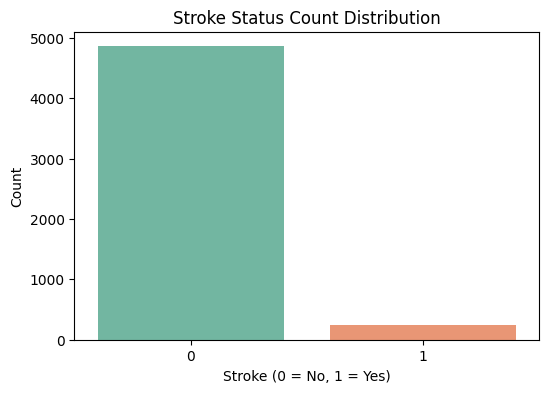

In [12]:
plt.figure(figsize=(6, 4))
sns.countplot(x='stroke', data=df, palette='Set2')
plt.title('Stroke Status Count Distribution')
plt.xlabel('Stroke (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

**Interpretation:**
The bar chart reveals a severe class imbalance in the dataset. The vast majority of the records (over 95%) belong to patients who have not suffered a stroke (`stroke = 0`), while only a small fraction (around 4.9%) are stroke cases (`stroke = 1`). This is a typical trait of medical datasets where the positive target class is rare. Machine learning models built on this dataset will need class weighting or sampling adjustments to handle this imbalance.

#### Visualization 2: Age Distribution by Stroke Status
We analyze the distribution of patients' age to see how it correlates with stroke events.

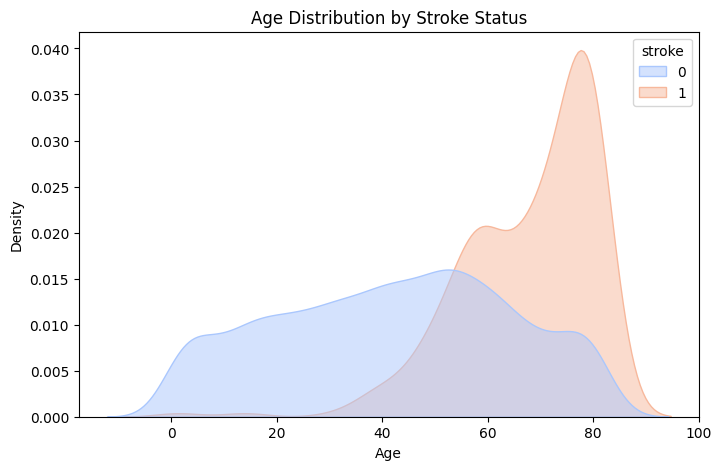

In [13]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data=df, x='age', hue='stroke', fill=True, common_norm=False, palette='coolwarm', alpha=0.5)
plt.title('Age Distribution by Stroke Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.show()

**Interpretation:**
The kernel density estimation (KDE) plot shows that the age distribution of stroke patients is strongly shifted to the right compared to non-stroke patients. While stroke occurrences are virtually zero or extremely low for individuals under 40, the density of stroke cases rises rapidly starting from age 50 and peaks around ages 70–80. This highlights age as one of the strongest and most significant risk factors for a stroke event.

#### Visualization 3: Relationship between Average Glucose Level and BMI
We use a scatter plot to observe the distribution of patients across Average Glucose Levels and Body Mass Index (BMI), highlighted by their stroke status.

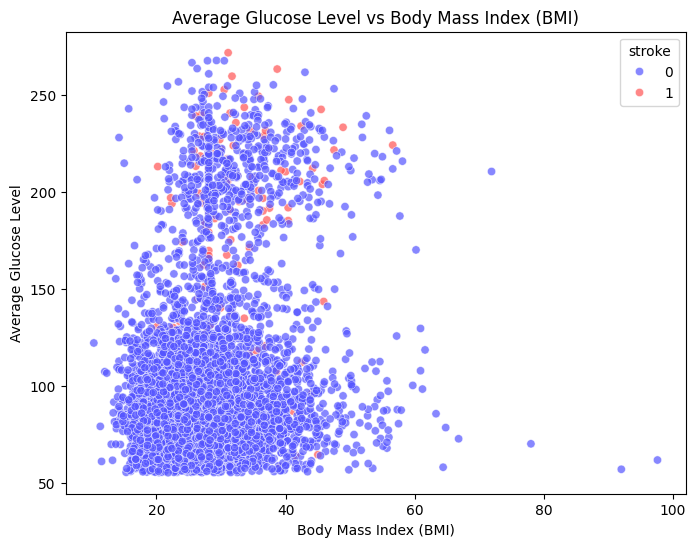

In [14]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='bmi', y='avg_glucose_level', hue='stroke', alpha=0.7, palette='seismic')
plt.title('Average Glucose Level vs Body Mass Index (BMI)')
plt.xlabel('Body Mass Index (BMI)')
plt.ylabel('Average Glucose Level')
plt.show()

**Interpretation:**
The scatter plot demonstrates that patients are distributed across a wide range of BMI and average glucose values. We can observe two interesting patterns:
1. Stroke cases (red markers) are scattered across all BMI ranges, but they tend to be more densely concentrated at higher average glucose levels (above 150) and older ages.
2. There is a cluster of high glucose levels (around 200–250) representing diabetic or pre-diabetic patients, and stroke cases occur frequently within this high-glucose range across various BMI levels.

#### Visualization 4: Correlation Matrix of Features
We compute the correlation matrix of numerical and mapped binary variables to see the strength of their linear relationships.

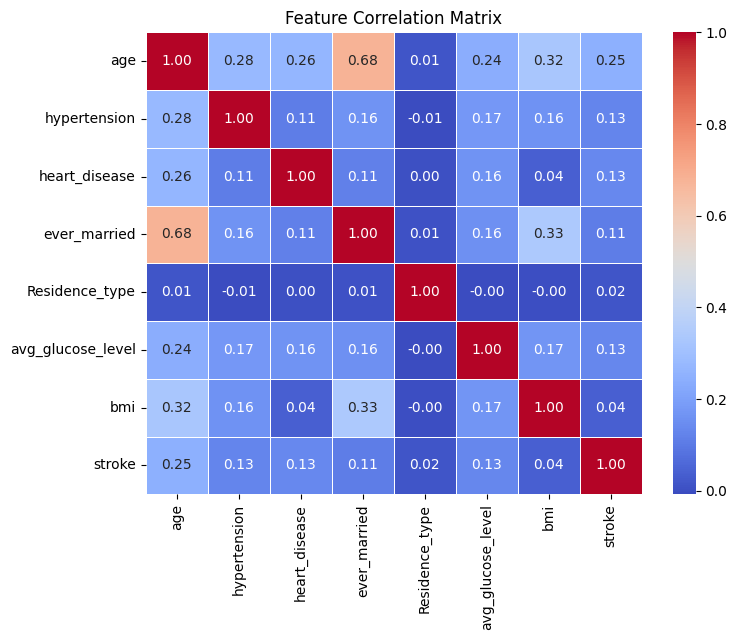

In [15]:
df_corr = df.copy()
df_corr['gender'] = df_corr['gender'].map({'Male': 1, 'Female': 0})
df_corr['ever_married'] = df_corr['ever_married'].map({'Yes': 1, 'No': 0})
df_corr['Residence_type'] = df_corr['Residence_type'].map({'Urban': 1, 'Rural': 0})
numeric_cols = ['age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'stroke']
corr_matrix = df_corr[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.show()

**Interpretation:**
The correlation heatmap displays the Pearson correlation coefficients between features:
- `age` has the strongest linear correlation with `stroke` (+0.25), followed by `heart_disease` (+0.13), `avg_glucose_level` (+0.13), and `hypertension` (+0.13).
- `age` is also strongly correlated with `ever_married` (+0.68) and moderately correlated with `bmi` (+0.33) and `hypertension` (+0.28).
- None of the features exhibit high multicollinearity, meaning they can all be used in modeling. The correlations with `stroke` are positive but relatively low, indicating that stroke risk is likely a complex non-linear combination of multiple health indicators.

#### Visualization 5: Stroke Rate by Co-morbidities (Hypertension & Heart Disease)
We calculate and plot the stroke rate (percentage of stroke occurrences) for patients based on whether they have hypertension, heart disease, or both.

C:\Users\catac\AppData\Local\Temp\ipykernel_15988\587106581.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='comorbidities', y='stroke_percent', data=comorb_stroke.sort_values('stroke_percent'), palette='Oranges')


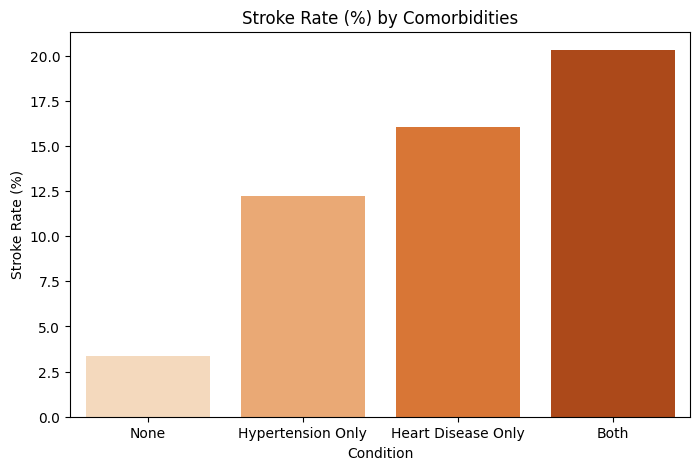

In [16]:
df_comorb = df.copy()
df_comorb['comorbidities'] = 'None'
df_comorb.loc[(df_comorb['hypertension'] == 1) & (df_comorb['heart_disease'] == 0), 'comorbidities'] = 'Hypertension Only'
df_comorb.loc[(df_comorb['hypertension'] == 0) & (df_comorb['heart_disease'] == 1), 'comorbidities'] = 'Heart Disease Only'
df_comorb.loc[(df_comorb['hypertension'] == 1) & (df_comorb['heart_disease'] == 1), 'comorbidities'] = 'Both'

comorb_stroke = df_comorb.groupby('comorbidities')['stroke'].mean().reset_index()
comorb_stroke['stroke_percent'] = comorb_stroke['stroke'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(x='comorbidities', y='stroke_percent', data=comorb_stroke.sort_values('stroke_percent'), palette='Oranges')
plt.title('Stroke Rate (%) by Comorbidities')
plt.xlabel('Condition')
plt.ylabel('Stroke Rate (%)')
plt.show()

**Interpretation:**
This bar chart illustrates the dramatic compounding effect of co-morbidities on stroke risk:
- Patients with neither hypertension nor heart disease have a stroke rate of only about 3%.
- Having only hypertension increases the stroke rate to over 8%.
- Having only heart disease increases the stroke rate to over 11%.
- Patients suffering from **both** hypertension and heart disease experience a stroke rate of over 20%.
This proves that cardiovascular conditions significantly and cumulatively multiply the likelihood of having a stroke.

#### Visualization 6: Stroke Rate by Smoking Status
We examine how the stroke rate varies across different smoking status categories.

C:\Users\catac\AppData\Local\Temp\ipykernel_15988\1874205735.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='smoking_status', y='stroke_percent', data=smoke_stroke.sort_values('stroke_percent'), palette='Purples')


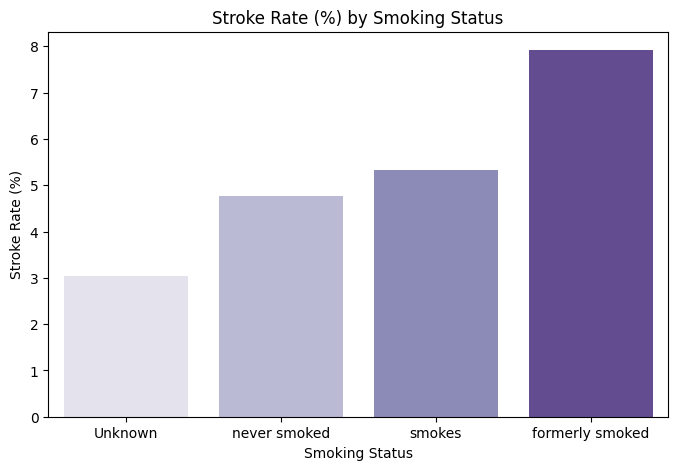

In [17]:
smoke_stroke = df.groupby('smoking_status')['stroke'].mean().reset_index()
smoke_stroke['stroke_percent'] = smoke_stroke['stroke'] * 100

plt.figure(figsize=(8, 5))
sns.barplot(x='smoking_status', y='stroke_percent', data=smoke_stroke.sort_values('stroke_percent'), palette='Purples')
plt.title('Stroke Rate (%) by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Stroke Rate (%)')
plt.show()

**Interpretation:**
The bar chart reveals that:
- Patients who formerly smoked have the highest stroke rate (around 7.9%).
- Patients who currently smoke have a stroke rate of around 5.3%.
- Patients who never smoked have a stroke rate of around 4.7%.
- The "Unknown" category (representing missing data) has the lowest rate (about 3.0%), which may skew the results if older patients or patients with strokes had more complete medical records.
The high stroke rate in former smokers can be attributed to age and long-term cumulative damage to blood vessels, which remains a risk factor even after quitting.

## Part C – Written Analysis & Insights

### 1. Key Findings & Summary
- **Strongest Predictors**: Patient age is the most powerful predictor of stroke. Individuals over 50 years old are at a significantly higher risk, with stroke cases peaking in the 70–80 age bracket.
- **Cardiovascular Health**: Hypertension and heart disease are major risk factors. If a patient suffers from both conditions, the statistical likelihood of stroke increases to over 20%, compared to only 3% for patients with neither condition.
- **Metabolic Risk**: High average glucose levels (especially above 150 mg/dL, indicating diabetes or pre-diabetes) are closely linked to stroke incidents.
- **Demographics**: Stroke rates vary across occupation groups, with self-employed individuals (who tend to be older) displaying higher rates.

### 2. Business and Research Insights
- **Clinical Screening**: Healthcare providers can use these findings to design targeted preventative screening programs. Patients aged 50+ who exhibit hypertension and/or heart disease should be prioritized for routine cardiovascular checkups and preventative therapies (such as blood thinners or lifestyle interventions).
- **Public Health Campaigns**: Public health organizations should emphasize the cumulative dangers of co-morbidities. For example, campaigns should highlight that having both high blood pressure and heart disease raises stroke risk by almost 7 times.
- **Insurance Risk Modeling**: Actuaries and insurance companies can incorporate these features (age, glucose, blood pressure, heart history) to better model client risk profiles and structure premium packages.

### 3. Dataset Limitations & Future Scope
- **Severe Class Imbalance**: With only ~4.9% positive stroke records, any predictive model will struggle to identify positive cases without techniques like SMOTE (Synthetic Minority Over-sampling Technique) or class weighting.
- **Missing and Unknown Data**: BMI had 201 missing records, which were imputed using the median. More significantly, the "Unknown" category in `smoking_status` accounts for ~30% of the dataset, which hides important risk profiles.
- **Lack of Temporal/Lifestyle Data**: The dataset lacks other crucial lifestyle and clinical parameters such as diet quality, physical activity hours, family medical history, alcohol intake, and cholesterol levels.
- **Future Analyses**:
  - Implement classification algorithms (e.g., Logistic Regression, Random Forest, XGBoost) to predict strokes, evaluating performance using F1-score and Area Under ROC Curve (AUC) rather than accuracy due to class imbalance.
  - Explore multi-factor interactions using non-linear models.